In [2]:
from industria.data import load_raw
from industria.features import add_features
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

In [3]:
df = add_features(load_raw())
df.shape

(10000, 17)

In [4]:
colunas_fora = ["Machine failure", "TWF","HDF","PWF","OSF","RNF","UDI","Product ID"]

In [5]:
y = df["Machine failure"]
x = df.drop(columns=colunas_fora)
x = pd.get_dummies(x, columns=["Type"], drop_first=True)
x.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'power',
       'temp_diff', 'strain', 'Type_L', 'Type_M'],
      dtype='str')

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
print("Treino: ", x_train.shape, " | Teste: ", x_test.shape)
print(y_test.mean().round(4), " | ", y_train.mean().round(4))

Treino:  (8000, 10)  | Teste:  (2000, 10)
0.034  |  0.0339


In [8]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train,y_train)
y_pred_dummy = dummy.predict(x_test)

In [9]:
print("Acuracia: ", round(accuracy_score(y_test, y_pred_dummy),4))
print("Recall (falhas): ", round(recall_score(y_test, y_pred_dummy),4))

Acuracia:  0.966
Recall (falhas):  0.0


In [10]:
modelo = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
modelo.fit(x_train,y_train)
y_forest_pred = modelo.predict(x_test) 

In [11]:
print("Acuracia: ", round(accuracy_score(y_test, y_forest_pred),4))
print("Recall (falhas): ", round(recall_score(y_test, y_forest_pred),4))


Acuracia:  0.9915
Recall (falhas):  0.8088


In [12]:
print(confusion_matrix(y_test, y_forest_pred))
print()
print(classification_report(y_test,y_forest_pred, digits=3))

[[1928    4]
 [  13   55]]

              precision    recall  f1-score   support

           0      0.993     0.998     0.996      1932
           1      0.932     0.809     0.866        68

    accuracy                          0.992      2000
   macro avg      0.963     0.903     0.931      2000
weighted avg      0.991     0.992     0.991      2000



In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
modelos = {
    "Logistica": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced")
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)

}

In [15]:
for nome, m in modelos.items():
    score = cross_val_score(m, x_train, y_train, cv=cv, scoring="f1")
    print(f"{nome}: f1 medio = {score.mean():.3f} (desvio: {score.std():.3f})")

Logistica: f1 medio = 0.271 (desvio: 0.011)
Random Forest: f1 medio = 0.857 (desvio: 0.027)
Gradient Boosting: f1 medio = 0.894 (desvio: 0.023)


In [16]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train,y_train)
y_pred_gb = gb.predict(x_test)

print(confusion_matrix(y_test, y_pred_gb))
print()
print(classification_report(y_test, y_pred_gb))

[[1932    0]
 [  14   54]]

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       1.00      0.79      0.89        68

    accuracy                           0.99      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       0.99      0.99      0.99      2000



In [17]:
y_proba_gb = gb.predict_proba(x_test)[:,1]
print("Probabilidades: ", y_proba_gb[:10].round(3))

Probabilidades:  [0.006 0.001 0.045 0.001 0.006 0.001 0.013 0.001 0.001 0.001]


In [18]:
y_pred_030 = (y_proba_gb >= 0.30).astype(int)

print()
print(confusion_matrix(y_test, y_pred_030))
print(classification_report(y_test,y_pred_030))


[[1929    3]
 [  11   57]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.84      0.89        68

    accuracy                           0.99      2000
   macro avg       0.97      0.92      0.94      2000
weighted avg       0.99      0.99      0.99      2000



In [19]:
custo_fn = 10
custo_fp = 1

melhor_th = 0.5
menor_custo = float("inf")

In [20]:

for th in np.arange(0.05, 0.96, 0.05):
    y_pred = (y_proba_gb >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    custo = fn * custo_fn + fp * custo_fp 
    if custo < menor_custo:
        menor_custo = custo
        melhor_th = th

print("Melhor threshold:", round(melhor_th, 2))
print("Custo minimo:", menor_custo)

Melhor threshold: 0.25
Custo minimo: 103


In [21]:
y_pred_final = (y_proba_gb >= 0.25).astype(int)

print(confusion_matrix(y_test, y_pred_final))
print()
print(classification_report(y_test, y_pred_final, digits=3))

[[1929    3]
 [  10   58]]

              precision    recall  f1-score   support

           0      0.995     0.998     0.997      1932
           1      0.951     0.853     0.899        68

    accuracy                          0.994      2000
   macro avg      0.973     0.926     0.948      2000
weighted avg      0.993     0.994     0.993      2000



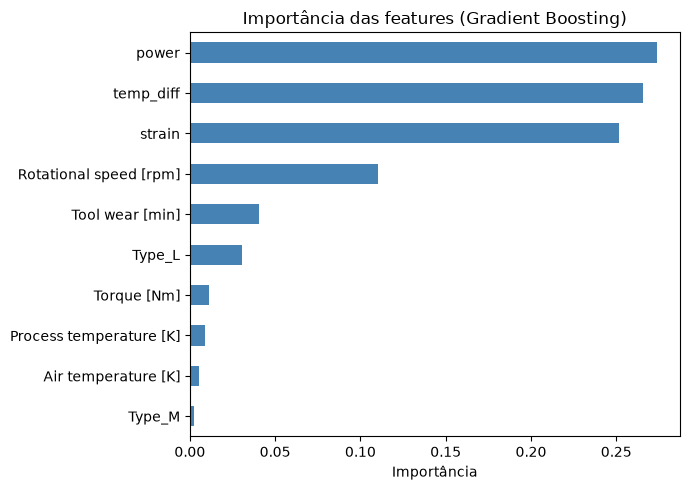

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(gb.feature_importances_, index=x_train.columns).sort_values()

importancias.plot(kind="barh", figsize=(7, 5), color="steelblue")
plt.title("Importância das features (Gradient Boosting)")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

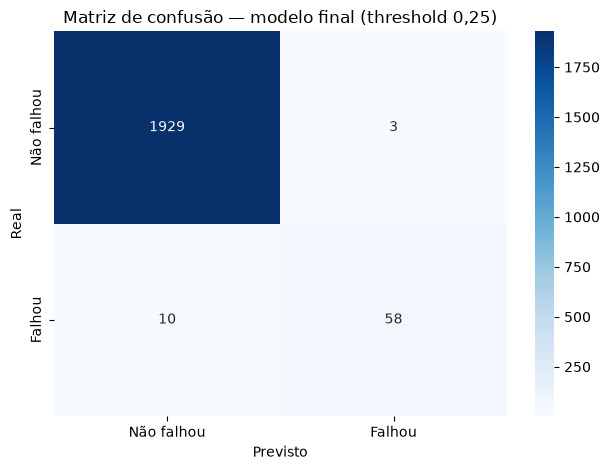

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Não falhou", "Falhou"],
            yticklabels=["Não falhou", "Falhou"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de confusão — modelo final (threshold 0,25)")
plt.tight_layout()
plt.show()